# MOD 3 - Pipeline HOG + SVM

## Progetto: Minecraft mob detection
## Autore: Aiman Hamdouni

Qui andremmo costruire un detector di mob usando feature handcrafted (HOG) e un classificatore classico (SVM), seguendo la pipeline tradizionale.

Alcune osservazioni:
- k-NN (Lazy learning) => non costruisce un modello, memorizza tutti i dati. Per predire calcola la distanza a tutti i punti di training e vota a maggioranza tra i k piu' vicini.
- SVM => Trova l'iperpiano ottimale che separa le classi massimizzando il margine. Il kernel trick permette di separare classi non linealmente separabili.
- Pipeline HOG+SVM => pipeline = data preparation -> HOG features -> SVM training -> sliding window detection -> NMS.

Quindi avremmo due path:
1. Training => Crop -> Grayscale -> Resize 64x128 -> HOG features -> SVM -> Classe predetta
Questo è quello che facciamo prima e una volta sola. Prendiamo i crop dei mob, estraiamo HOG, addestriamo SVM. Il risultato è un modello salvato.

2. Detection => Test image -> Image Pyramid -> Sliding Window -> HOG+SVM -> NMS -> Detection
Questo è quello che facciamo a runtime, su ogni nuova immagine. Prendiamo l'immagine intera, la scaliamo a diverse risoluzioni, facciamo scorrere la finestra 64x128, classifichiamo ogni finestra con il modello già addestrato, applichiamo NMS per rimuovere i duplicati.

- Performance Evaluation => Confusion matrix, precision, recall, F1, mAP, IoU.


## 1. Setup e caricamento dataset (REVISIONATO)

In [5]:
# GESTISCO LA PARTE DI CARICAMENTO LIBRERIE ---------------------------------------------

# Qui carico tutte le librerie che mi potrebbero tornare utili
# Installiamo kagglehub per scaricare il dataset da Kaggle
!pip install kagglehub

import kagglehub                      # kagglehub (libreria per scaricare il dataset)
import cv2                            # OpenCV (libreria per computer vision)
import numpy as np                    # NumPy (libreria per lavorare con le immagini come matrici di valori)
import matplotlib.pyplot as plt       # Matplotlib.pyplot (libreria per visualizzare immagini o grafici)
import matplotlib.patches as patches  # Matplotlib.patches (mi serve per creare i rettangolo intorno ai mobi identificati)
from pathlib import Path              # Path (libreria che mi serve per gestire i percorsi dei file in modo semplice infatti mi basta dichiarare il path poi dopo la sotto cartelal
                                      # e file text ad esempio Path("/cartella") / "sottocartella" / "file.formato poi gestisce sia lo "\" che questo "/"
from collections import Counter       # Counter (liberia utile per fare il conteggio in lista)
import random                         # Random (per scegliere elementi casuali da una lista)

# Librerie per il machine learning classico
from sklearn.svm import LinearSVC, SVC             # I due classificatori SVM che useremo
from sklearn.neighbors import KNeighborsClassifier # k-NN come baseline
from sklearn.preprocessing import StandardScaler   # Per normalizzare le feature
from sklearn.model_selection import train_test_split # Per dividere in train e test

from sklearn.metrics import (
    accuracy_score,          # percentuale di predizioni corrette
    confusion_matrix,        # tabella degli errori per classe
    classification_report    # precision, recall, F1 per ogni classe
)
import seaborn as sns  # Per grafici piu' belli (heatmap della confusion matrix)

# Seed per riproducibilita'
random.seed(44)
np.random.seed(44)

# Controllo se sono caricate
print("\nLE LIBRERIE SONO STATE CARICATE")

# GESTISCO LA PARTE DI COLORI TRA LE CLASSI ---------------------------------------------

# Nomi e colori delle classi (identico a quello che abbiamo fatto in MOD1)
nomi_classi = {0: "Creeper", 1: "Skeleton", 2: "Spider", 3: "Zombie"}
colori_classi = {
    0: (0, 200, 0),      # Verde per il Creeper
    1: (200, 200, 200),  # Grigio per lo Skeleton
    2: (139, 69, 19),    # Marrone per lo Spider
    3: (100, 149, 237),  # Blu per lo Zombie
}
lista_classi = [nomi_classi[i] for i in range(4)]  # ["Creeper", "Skeleton", "Spider", "Zombie"]
numero_classi = len(nomi_classi)  # 4

# GESTISCO LA PARTE DI PATH ---------------------------------------------

# Scarichiamo il dataset
percorso_dataset = kagglehub.dataset_download("dracotlw/minecraft-mobs-yolo-dataset")

# Path() converte la stringa del percorso dove "/" seve per concantenare il percorso verso le cartelle
# "minecraft_mobs_yolo" è la mia sottocartella del dataset
cartella_base = Path(percorso_dataset) / "minecraft_mobs_yolo"

# Qui mi salvo tutti i percorsi a delle cartelle dove ho le mie immagini che mi servono per il train e il testing
cartella_img_train = cartella_base / "train" / "images"
cartella_img_val   = cartella_base / "val"   / "images"
# Qui mi salvo tutti i percorsi a delle cartelle dove ho le annotazione dei file txt delle immagini per il train e il test
cartella_lbl_train = cartella_base / "train" / "labels"
cartella_lbl_val   = cartella_base / "val"   / "labels"

# Verifichiamo che i percorsi esistano
print("\nVERIFICA SE CI SONO I PERCORSI SALVATI")
print(cartella_img_train)
print(cartella_img_val)

# Raccogliamo la lista di tutte le immagini training
lista_jpg = list(cartella_img_train.glob("*.jpg"))   # tutti i .jpg
lista_png = list(cartella_img_train.glob("*.png"))   # tutti i .png
lista_immagini_train = sorted(lista_jpg + lista_png) # uniamo e ordiniamo

print(f"\nImmagini training= {len(lista_immagini_train)}")

# GESTISCO FUNZIONE PER LA LETTURA FILE ANNOTAZIONE TXT ---------------------------------------------

# Funzione per leggere un file annotazione YOLO
def leggi_annotazione_yolo(percorso_label):

    # Legge un file .txt YOLO e restituisce la lista dei bounding box.
    # Ogni riga del file = un mob = una tupla (classe, xc, yc, w, h).

    lista_box = []
    percorso = Path(percorso_label)

    if not percorso.exists():
        return lista_box  # file non esiste => nessun mob

    contenuto = percorso.read_text().strip()
    if contenuto == "":
        return lista_box  # file vuoto => nessun mob

    for riga in contenuto.split("\n"):
        parti = riga.strip().split()  # dividiamo per spazi
        if len(parti) == 5:
            id_classe = int(parti[0])
            xc = float(parti[1])
            yc = float(parti[2])
            w  = float(parti[3])
            h  = float(parti[4])
            lista_box.append((id_classe, xc, yc, w, h))

    return lista_box



LE LIBRERIE SONO STATE CARICATE
Using Colab cache for faster access to the 'minecraft-mobs-yolo-dataset' dataset.

VERIFICA SE CI SONO I PERCORSI SALVATI=
/kaggle/input/minecraft-mobs-yolo-dataset/minecraft_mobs_yolo/train/images
/kaggle/input/minecraft-mobs-yolo-dataset/minecraft_mobs_yolo/val/images

Immagini training= 2068


## 1. Data Preparation  (crop positivi e negativi) (REVISIONATO)

Sappiamo che lo standard del passato era HOG+SVM che era organizzata in questa pipeline:

1. Data Preparation crop positivi (mob) e negativi (background)
2. Feature Extraction HOG da tutti i crop
3. Classifier Training SVM su feature HOG + etichette
4. Detection: sliding window + HOG + SVM + NMS

La dimensione 64x128 (standard)

In [6]:
# STESSA ATTIVITA DI PRE PROCESSING VISTA IN MOD 2, cambia solo che ho accorpato la funzione
# di lettura txt sopra e poi qui sono già aggiunti la parte di equalization e augmentation (con il flip)

#RITAGLIO POSITIVO DEI MIEI CROP (IN PRATICA PRENDO IL BOUNDING BOX DOVE CE IL MIO MOB LO RITAGLIO E POI LO RIDIMENSIONO PER 64X128)--------------------------------

# Dimensione standard per HOG (larghezza x altezza)
dimensione_hog = (64, 128)

# CROP POSITIVI: ritagliamo i mob dai bounding box -
lista_crop_positivi = []   # lista dei crop (immagini 64x128 grayscale)
lista_etichette     = []   # lista delle classi corrispondenti
contatore_per_classe = Counter()  # conta quanti crop per ogni classe
massimo_per_classe   = 300        # limite per non sbilanciare troppo

for immagine in lista_immagini_train:
    file_label = cartella_lbl_train / (immagine.stem + ".txt")

    # Leggiamo le annotazioni di questa immagine
    lista_box  = leggi_annotazione_yolo(file_label)

    # Soliti controlli per vedere se esiste il txt è quindi un mob nell'immagine
    if not lista_box:
        continue  # nessun mob, saltiamo

    # Carichiamo l'immagine
    img_bgr = cv2.imread(str(immagine))
    if img_bgr is None:
        continue

    altezza, larghezza = img_bgr.shape[:2] # qui prendiamo le due dimensioni altezza e larghezza dell'image

    # Prendo il txt è lo metto in lista e poi ci ciclo potrei avere + mob in un immagine (è già splitato da una funzione dichiarata sopra per la lettura dei txt)
    for box in lista_box:
        id_classe, xc, yc, bw, bh = box

        # Saltiamo classi non valide (es. classe 4 = background)
        if id_classe not in nomi_classi:
            continue

        # Controlliamo il limite per classe => voglio che per classe si hanno solo 300 (per balance)
        if contatore_per_classe[id_classe] >= massimo_per_classe:
            continue

        # Convertiamo da normalizzato  a pixel
        x1 = max(0, int((xc - bw/2) * larghezza))
        y1 = max(0, int((yc - bh/2) * altezza))
        x2 = min(larghezza, int((xc + bw/2) * larghezza))
        y2 = min(altezza, int((yc + bh/2) * altezza))

        # Saltiamo crop troppo piccoli
        if x2 - x1 < 10 or y2 - y1 < 10:
            continue

        # Ritagliamo e convertiamo in grayscale
        ritaglio = img_bgr[y1:y2, x1:x2]
        ritaglio_gray = cv2.cvtColor(ritaglio, cv2.COLOR_BGR2GRAY)

        # Applichiamo histogram equalization per uniformare il contrasto
        ritaglio_eq = cv2.equalizeHist(ritaglio_gray)

        # Ridimensioniamo a 64x128 (i miei crop ritagliati)
        ritaglio_finale = cv2.resize(ritaglio_eq, dimensione_hog)

        lista_crop_positivi.append(ritaglio_finale)
        lista_etichette.append(id_classe)
        contatore_per_classe[id_classe] += 1

        # Aggiungiamo anche il flip orizzontale come augmentation
        # cv2.flip(img, 1): 1=flip orizzontale
        if contatore_per_classe[id_classe] < massimo_per_classe:
            ritaglio_flip = cv2.flip(ritaglio_finale, 1)
            lista_crop_positivi.append(ritaglio_flip)
            lista_etichette.append(id_classe)
            contatore_per_classe[id_classe] += 1

print(f"Crop positivi estratti= {len(lista_crop_positivi)}")
for id_c, conteggio in sorted(contatore_per_classe.items()):
    print(f"{nomi_classi[id_c]}= {conteggio}")

#RITAGLIO NEGATIVO (PRENDO L'IMMAGINE, SCELGO UNA SEZIONE A CASO TAGLIANDOLA E POI LO RIDIMENSIONO PER 64X128)--------------------------------

# CROP NEGATIVI= patch casuali dalle background images
lista_crop_negativi = []
numero_negativi = len(lista_crop_positivi)  # bilanciamo con i positivi

# Troviamo le background images
lista_background = []
for immagine in lista_immagini_train:
    file_label = cartella_lbl_train / (immagine.stem + ".txt")

    # Controllo per prendere solo sfondi senza mob (basta solo la verifica sul txt)
    if not file_label.exists():
        lista_background.append(immagine)
    elif file_label.read_text().strip() == "":
        lista_background.append(immagine)

# Quanti crop per ogni background image?
# Allora se io devo raggiungere come target dei crop 800 (vedi ritagli positivi), ma se
# so che image background ne ho solo la metà quindi 400 allora per ogni image devo estrarre almeno due crop casuali per arrivare 800
# + 1 perchè arrotondamento è per difetto quindi il rischio di avere meno crop, ma posso avere + crop rispetto positivi?
# si ma lo gestisco dopo con un if quindi è meglio averne una piu che un in meno
crop_per_immagine = max(1, numero_negativi // len(lista_background)) + 1

for immagine_bg in lista_background:
    img_bg = cv2.imread(str(immagine_bg))

    #Controllo come quello precedente, ci deve essere l'immagine
    if img_bg is None:
        continue

    altezza_bg, larghezza_bg = img_bg.shape[:2]
    gray_bg = cv2.cvtColor(img_bg, cv2.COLOR_BGR2GRAY)
    gray_bg = cv2.equalizeHist(gray_bg)  # # grayscale per HOG (richiesto)
    # Come ho detto prima HOG ha come standard il grayscale però calcola il gradiente per ogni
    # pixel vicino, per fare questo ha bisogno un unico valore per pixel e non tre valori (blu, verde, rosso)


    largh_hog, altez_hog = dimensione_hog  # 64, 128 (standard hog)

    for _ in range(crop_per_immagine):

        # Usciamo se abbiamo abbastanza negativi
        if len(lista_crop_negativi) >= numero_negativi:
            break

        # L'immagine deve essere abbastanza grande per il crop (un controllo ulteriore che non guasta in caso avessi immagini piccole)
        if larghezza_bg < largh_hog or altezza_bg < altez_hog:
            continue

        # Posizione casuale del crop
        # Il limite massimo e' (larghezza - 64) per non uscire dai bordi dell'immagine
        x = random.randint(0, larghezza_bg - largh_hog)
        y = random.randint(0, altezza_bg - altez_hog)

        # Ritagliamo il pezzo di immagine: righe da y a y+128, colonne da x a x+64
        crop_bg = gray_bg[y:y+altez_hog, x:x+largh_hog]
        lista_crop_negativi.append(crop_bg)

print(f"Crop negativi estratti= {len(lista_crop_negativi)}")
print(f"Totale= {len(lista_crop_positivi) + len(lista_crop_negativi)} crop pronti per HOG+SVM")

Crop positivi estratti= 1200
Creeper= 300
Skeleton= 300
Spider= 300
Zombie= 300
Crop negativi estratti= 1200
Totale= 2400 crop pronti per HOG+SVM


## 2. HOG Feature Extraction (REVISIONATO)

HOG descrive la forma di un oggetto attraverso la distribuzione locale dei gradienti.

Come funziona passo per passo:
1. Calcola il gradiente (Sobel) per ogni pixel, quindi magnitudo e direzione
2. Divide l'immagine in celle 8x8 pixel
3. In ogni cella crea un istogramma con 9 bin delle direzioni (0-180 gradi)
4. Raggruppa celle in blocchi 2x2 (16x16 px) e normalizza
5. Concatena tutti gli istogrammi in un unico vettore

Dimensione del vettore finale:
- Blocchi => (64-16)/8+1 = 7 per riga, (128-16)/8+1 = 15 per colonna
- Totale => 7 x 15 x 4 celle x 9 bin = 3780 feature per immagine

In [7]:
# Inizializziamo il HOG Descriptor
# cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, nbins)

# È la dimensione dell'immagine di input. Ogni crop che diamo a HOG deve essere esattamente 64x128 pixel. Per questo abbiamo fatto il resize prima.
dimensione_finestra = dimensione_hog  # (64, 128 dimensione immagine input)

# HOG raggruppa le celle in blocchi 2x2 (16x16 pixel = 2 celle x 8px). Su ogni blocco normalizza i valori per renderli più robusti a cambiamenti di illuminazione.
dimensione_blocco= (16, 16) # blocco di normalizzazione (2x2 celle)

# HOG divide l'immagine in celle di 8x8 pixel. In ogni cella calcola il gradiente di tutti i 64 pixel e crea un istogramma delle direzioni.
stride_blocco = (8, 8)  # spostamento tra blocchi (50% overlap)
dimensione_cella = (8, 8) # cella base per il calcolo del gradiente

#L'istogramma di ogni cella ha 9 bucket. Ogni secchiello raccoglie i gradienti in un range di direzione di 20 gradi (9 bin × 20° = 180° totali).
numero_bin = 9 # 9 bin = 20 gradi ciascuno (da 0 a 180)

#COMMENTO OLD
# Ricapitolando abbiamo:
# Immagine 64x128 => È il punto di partenza. Tutti i crop hanno la stessa dimensione fissa perché HOG deve produrre sempre un vettore della stessa lunghezza.
# Blocchi 16x16 (con stride 8, si sovrappongono) => Raggruppa 4 celle vicine e normalizza i loro istogrammi insieme. Serve per la robustezza all'illuminazione, ovvero se una zona dell'immagine è più luminosa
#                                                   (es: un lato del mob illuminato), la normalizzazione riduce questo effetto. L'overlap (50%) fa sì che ogni cella venga normalizzata più volte con contesti diversi.
# Celle 8x8 (4 celle per blocco) => Sono le unità base di analisi. In ogni cella HOG guarda come cambia l'intensità tra pixel vicini (il gradiente). Questo cattura i bordi locali del mob, es: contorno braccio del mob
# Istogramma 9 bin per cella => In ogni cella raggruppa i gradienti per direzione. Non ci interessa dove esattamente è il bordo, ma in che direzione va.
#                               Un bordo verticale finisce nel bin 90°, uno orizzontale nel bin 0°. Questo rende HOG robusto a piccole variazioni di posizione.

#COMMENTO NEW
# Step più semplici:
# STEP 1 = parto da immagini già croppate dei mob 64x128
#          UTILITA? avere immagini con la stessa dimensione in inpu, i vettori ottenuti dal hog devono avere la stessa lunghezza, così che SVM può confrontarli

# STEP 2 = divido questo crop 64x128 in piccole celle 8x8 ovvero 64/8 = 8 colonne e 128/8 = 16 righe => 8 X 16 = 128 celle totali
#          UTILITA? serve per analizzare i bordi locali dei mob, quindi invece di guarda l'intera immagine, hog lo divide in piccole zone e in ogni zona ci clacola il gradiente
#          quanto cambia l'intesità tra pixel vicini e questo permette di catturare i contorni locali, ad esempio bordo di un braccio o sagome della testa di un mob

# STEP 3 = in queste piccole celle che ho diviso (all'interno del crop 64x128) raggruppo 4 celle vicine in un blocco da 16x16 pixel, dove poi avrà un overlap del 50% di 8 pizel
#          Quando parlo di blocco 16x16 e come se avessi 4 celle dove ogni cella è 8x8 quindi il blocco da 16x16 sarebbe due celle in verticale (8+8) e due in orizzontale (8+8)
#          UTILITA? serve per la robustezza all'illuminazione, se una parte del mob è in ombra e l'altra illuminata i gradienti avrano intesità diverse, normalizzare 4 celle insieme riduce questo effetto
#          poi l'overlap del 50% fa si che ogni cella venga normalizzata più volte icont contesti diversi, da maggior stabilità

# STEP 4 = per ogni cella 16x16 gli raggruppo in 9 bucket (0°, 20°. 40° ... fino 180°) per direzione, ogni bin copre 20°. Un bordo verticale finisce nel nin 90° invece quello orizzontale nel 0°
#          UTILITA? serve per descrivere la direzione dei bordi invece della loro posizione esatta, quindi ci interessa solo se è un bordo verticale o orizzontale, rendendo hog robusto alle variazioni di posizioni del mob
#
# STEP 5 = creo il mio vettore finale dato da
#           BLOCCHI (105) => blocco 16x6 pixel che si sposta per 8 pixel alla volta, movimento orizzontale (64-16)/8+1 = 7 blocchi e movimento verticale (128-16)/8+1 = 15 blocchi => 7 * 15 = 105 blocchi
#           CELLE (4) => 4 celle per blocco, dove ogni blocco è 16x16 pixel e lo spostamento è di 8 pixel per volta, in orizzontale 16/8 = 2 e in verticale 16/8 = 2 => 2*2 = 4 celle per blocco
#           BIN (9 BUCKET)
#           BLOCCHI X CELLE X BIN = 105 X 4 X 9 = 3780 FEATURE
#           UTILITA? faccio la reppresentazione numerica della forma del mob, SVM lavora con numeri e non immagini, questo vettore di 3780 numeri descrive la forma del mob


# Creiamo il descriptor con i parametri scelti
hog_descriptor = cv2.HOGDescriptor(
    dimensione_finestra,
    dimensione_blocco,
    stride_blocco,
    dimensione_cella,
    numero_bin
)

# Testiamo su un crop di esempio
crop_esempio  = lista_crop_positivi[0]                     # un crop qualsiasi
vettore_hog   = hog_descriptor.compute(crop_esempio)       # calcoliamo HOG

# .flatten() trasforma l'array 2D (3780,1) in 1D (3780,)
vettore_hog_1d = vettore_hog.flatten()

print("Parametri HOG:")
print(f"Dimensione finestra: {dimensione_finestra}")
print(f"Dimensione blocco:{dimensione_blocco}")
print(f"Dimensione cella:{dimensione_cella}")
print(f"Numero bin:{numero_bin}")
print(f"Vettore HOG shape:{vettore_hog_1d.shape}")
print(f"= {vettore_hog_1d.shape[0]} feature per immagine")

# Calcoliamo HOG per tutti i crop (positivi e negativi)
# Il risultato e' una matrice => ogni riga = un crop, ogni colonna = una feature HOG

# CALCOLO HOG PER I CROP POSITIVI (OVVERO QUELLI CON MOB) ------------------------------------------

print("\nCalcolo HOG per i crop positivi")

# Lista che conterrà i vettori HOG di tutti i crop positivi
lista_feature_positive = []

# Qua cerco di gestirmela in questo modo se prima avevamo su un unica colonna gli metto tutti su una riga, per ogni append ho incremento di riga (passando righe crop e colonne feature hog)
for crop in lista_crop_positivi:
    # hog_descriptor.compute() restituisce shape (3780, 1)
    # .flatten() la trasforma in (3780,) un array 1D
    vettore = hog_descriptor.compute(crop).flatten() #1D semplice da gestire in lista (prima ho x righe e 1 colonna, ora ho solo una riga e basta)
    lista_feature_positive.append(vettore)

# Convertiamo la lista in una matrice NumPy, quindi avendo una lista composta da n liste di valori legati feature per hog lo trasformo in matrice 2D richiesto da SVM in input
# np.array(lista) trasforma una lista di array in una matrice 2D
# shape finale: (numero_crop, 3780)
matrice_positivi = np.array(lista_feature_positive, dtype=np.float32) #Qui lo riconvertiamo in 2D perchè costruiamo la matrice con riga i crop e colonna le feature

print(f"Shape matrice positivi: {matrice_positivi.shape}")


# CALCOLO HOG PER I CROP NEGATIVI (OVVERO QUELLI SENZA MOB) ------------------------------------------


print("\nCalcolo HOG per i crop negativi")
lista_feature_negative = []
for crop in lista_crop_negativi:
    vettore = hog_descriptor.compute(crop).flatten() #1D semplice da gestire in lista
    lista_feature_negative.append(vettore)

matrice_negativi = np.array(lista_feature_negative, dtype=np.float32) #Qui lo riconvertiamo in 2D perchè costruiamo la matrice con riga i crop e colonna le feature
print(f"Shape matrice negativi: {matrice_negativi.shape}")

# Uniamo positivi e negativi in un unico dataset
# np.vstack() impila le matrici verticalmente (una sopra l'altra)
X_tutto = np.vstack([matrice_positivi, matrice_negativi])


# CREO UN VETTORE CHE ASSOCIA PER OGNI RIGA LA CLASSIFICAZIONE DEI CROP (IL VETTORE è L'UNIONE TRA VETTORE CON MOB E QUELLI CON BACKGROUND) ------------------------------------------

# Creiamo le etichette o variabili target Y:
# - Positivi=> 0,1,2,3 (la classe del mob)
# - Negativi=> 4 (background)
y_tutto = np.concatenate([
    np.array(lista_etichette),           # 0,1,2,3 per i mob, converte la lista in un array numpy
    np.full(len(lista_crop_negativi), 4) # 4 per i background, qui creo una lista lunga di valori 4
])

print(f"\nDataset finale:")
print(f"X shape: {X_tutto.shape}  (campioni X feature)")
print(f"y shape: {y_tutto.shape}")


Parametri HOG:
Dimensione finestra: (64, 128)
Dimensione blocco:(16, 16)
Dimensione cella:(8, 8)
Numero bin:9
Vettore HOG shape:(3780,)
= 3780 feature per immagine

Calcolo HOG per i crop positivi
Shape matrice positivi: (1200, 3780)

Calcolo HOG per i crop negativi
Shape matrice negativi: (1200, 3780)

Dataset finale:
X shape: (2400, 3780)  (campioni X feature)
y shape: (2400,)


## 3. Train/Test Split e Scaling (REVISIONATO)

- Si fa lo split dei dati quindi dividiamo in training (75%) e test (25%). stratify mantiene le proporzioni delle classi.
- SVM e' sensibile alla scala delle feature. Con 3780 feature che hanno range diversi, infatti quelle con valori piu' grandi dominerebbero la distanza euclidea. StandardScaler risolv equesto problema portando ogni feature a media=0 e varianza=1.

In [8]:
# Dividiamo il dataset in training (75%) e test (25%)
# stratify=y_tutto => mantiene le proporzioni delle classi in entrambi i set
# random_state=42 => split riproducibile
X_train, X_test, y_train, y_test = train_test_split(
    X_tutto, y_tutto,
    test_size=0.25,
    random_state=42,
    stratify=y_tutto
)

# StandardScaler=> normalizza ogni feature a media=0 e varianza=1
# Formula=> x_scaled = (x - media) / deviazione_standard
scaler = StandardScaler()

# Il fit_transform solo sul training set, altrimenti contamino con informazioni di test che non dovrebbe vedere
# Infatti se facessimo fit anche sul test, useremmo informazioni del test per lo scaling
# e questo si chiama data leakage, ciò falsifica le metriche finali
X_train_scalato = scaler.fit_transform(X_train)  # impara i parametri e trasforma
X_test_scalato  = scaler.transform(X_test)        # usa i parametri gia' imparati

print("Statistiche dataset:")
print(f"Training:{X_train_scalato.shape[0]} campioni")
print(f"Test:{X_test_scalato.shape[0]} campioni")
print(f"Feature:{X_train_scalato.shape[1]} per campione\n")
print("Distribuzione classi nel training:")
contatore_train = Counter(y_train.astype(int))
for classe, conteggio in sorted(contatore_train.items()):
    nome = nomi_classi.get(classe, "Background")
    print(f"Classe{classe}({nome}):{conteggio}")


Statistiche dataset:
Training:1800 campioni
Test:600 campioni
Feature:3780 per campione

Distribuzione classi nel training:
Classe0(Creeper):225
Classe1(Skeleton):225
Classe2(Spider):225
Classe3(Zombie):225
Classe4(Background):900


## 4. Baseline k-nn (REVISIONATO)

Usiamo il knn come comparazione, se knn dovesse essere migliore rispetto a SVM vuol dire che ho sbagliato qualcosa perchè non è in grado di gestire la alta dimensionalità e di conseguenza dovrà essere una comparazione in un SVM vince sicuro.

Info utili su knn:
- Semplice e intuivo
- Nessun training time (infatti è un lazy learning quindi non costruisce un modello, memorizza tutti i dati)
- Versatile con più classi

Ma:
- Predizione lenta
- Sensibile al rumore con k piccoli
- Non gestisce bene la alta dimensionalità (qui sicuramente va a male con 3780 feature)


In [10]:
# Proviamo k-NN con diversi valori di k per trovare il migliore
# k dispari, evita pareggi nella votazione (es: se vicino 1 è zombie, vicino 2 è zombie, vicino 3 è skeleton e vicino 4 è skeleton, avendo k pari non saprebbe chi scegliere)
valori_k = [1, 3, 5, 7, 9]
k_migliore    = -1
accuracy_migliore = 0.0

print("Training k-NN con diversi valori di k")
for k in valori_k:
    # KNeighborsClassifier => classificatore k-NN di scikit-learn
    # n_neighbors=k => numero di vicini da consultare
    classificatore_knn = KNeighborsClassifier(n_neighbors=k)

    # .fit() => "allena" il modello (per k-NN => memorizza i dati)
    classificatore_knn.fit(X_train_scalato, y_train)

    # .predict() => predice le classi per il test set
    predizioni_knn = classificatore_knn.predict(X_test_scalato)

    # accuracy_score()=> percentuale di predizioni corrette
    accuratezza = accuracy_score(y_test, predizioni_knn)

    print(f"k={k}: accuracy = {accuratezza:.4f}")

    if accuratezza > accuracy_migliore:
        accuracy_migliore = accuratezza
        k_migliore = k

print(f"\nMiglior k-NN: k={k_migliore}, accuracy={accuracy_migliore:.4f}")
print("Questo e' il nostro baseline o punto di partenza da battere con SVM.")

# Con k=1 guarda solo ivicno più simile ma risulta essere sensibile al rumore, infatti se quel vicino è un caso strano sbaglierà
# Con k=3 guarda i 3 vicini, quindi più stabile

Training k-NN con diversi valori di k
k=1: accuracy = 0.8433
k=3: accuracy = 0.8250
k=5: accuracy = 0.8167
k=7: accuracy = 0.8117
k=9: accuracy = 0.8117

Miglior k-NN: k=1, accuracy=0.8433
Questo e' il nostro baseline o punto di partenza da battere con SVM.


## 5. Training SVM (REVISIONATO)

Come funziona SVM (Support Vector Machines)?

Funziona che dobbiamo trovare l'iperpiano che separa le classi massimizzando il margine => Il margine e' la distanza tra l'iperpiano e i punti piu' vicini (support vectors).

Altre nozioni importanti:
- Parametro C(regolarizzazione):
1. C grande => margine stretto, pochi errori sul training (rischio overfitting)
2. C piccolo => margine largo, piu' errori tollerati (piu' generalizzazione)
- Kernel trick => se i dati non sono linealmente separabili, li mappiamo in uno spazio piu' alto dove diventano separabili, senza calcolare la mappatura esplicitamente.
- Versione SVM?
1. Linear => veloce, funziona bene con HOG
2. RBF => piu' potente ma piu' lento


In [13]:
# Alleniamo due varianti di SVM e confrontiamo

# SVM VARIANTE LINEAR ------------------------------------------

print("Training SVM Lineare")

# LinearSVC => implementazione ottimizzata per kernel lineare
# C=1.0 => valore standard di regolarizzazione
# max_iter=10000 => numero massimo di iterazioni per convergere
svm_lineare = LinearSVC(C=1.0, max_iter=10000, random_state=42)
svm_lineare.fit(X_train_scalato, y_train)   # alleniamo il modello

predizioni_lineare = svm_lineare.predict(X_test_scalato)  # prediciamo sul test
accuracy_lineare = accuracy_score(y_test, predizioni_lineare)

print(f"Accuracy: {accuracy_lineare:.4f}")

# SVM VARIANTE RBF ------------------------------------------

print("\nTraining SVM RBF")

# SVC con kernel RBF => piu' potente ma piu' lento
# C=10.0 => margine piu' stretto
# gamma='scale' => calcola gamma automaticamente dai dati
svm_rbf = SVC(C=10.0, kernel='rbf', gamma='scale', random_state=42)
svm_rbf.fit(X_train_scalato, y_train)

predizioni_rbf  = svm_rbf.predict(X_test_scalato)
accuracy_rbf = accuracy_score(y_test, predizioni_rbf)

print(f"Accuracy: {accuracy_rbf:.4f}")

# Confronto finale
print("\nRIEPILOGO:")

print(f"{'k-NN (k='+str(k_migliore)+')'} {accuracy_migliore}")
print(f"{'SVM Lineare: '} {accuracy_lineare}")
print(f"{'SVM RBF: '} {accuracy_rbf}")

# Scegliamo il modello migliore
if accuracy_lineare >= accuracy_rbf:
    svm_migliore = svm_lineare
    nome_svm = "SVM Lineare"
    predizioni_migliori = predizioni_lineare
else:
    svm_migliore = svm_rbf
    nome_svm = "SVM RBF"
    predizioni_migliori = predizioni_rbf

print(f"\nModello scelto: {nome_svm}")


Training SVM Lineare
Accuracy: 0.8350

Training SVM RBF
Accuracy: 0.9100

RIEPILOGO:
k-NN (k=1) 0.8433333333333334
SVM Lineare:  0.835
SVM RBF:  0.91

Modello scelto: SVM RBF


## 6. Performance Evaluation (REVISIONATO)

Metriche Base:
- Confusion Matrix => tabella che confronta predizioni vs verita'. La diagonale = predizioni corrette. Fuori diagonale = errori.
- Precision => di tutti i positivi predetti, quanti erano corretti? => P = TP / (TP + FP) => misura la purezza delle predizioni.
- Recall => di tutti i positivi reali, quanti ne ho trovati? => R = TP / (TP + FN) => misura la capacita' di non perdere positivi.
- F1 => media armonica di P e R. Alto solo se entrambi sono alti.

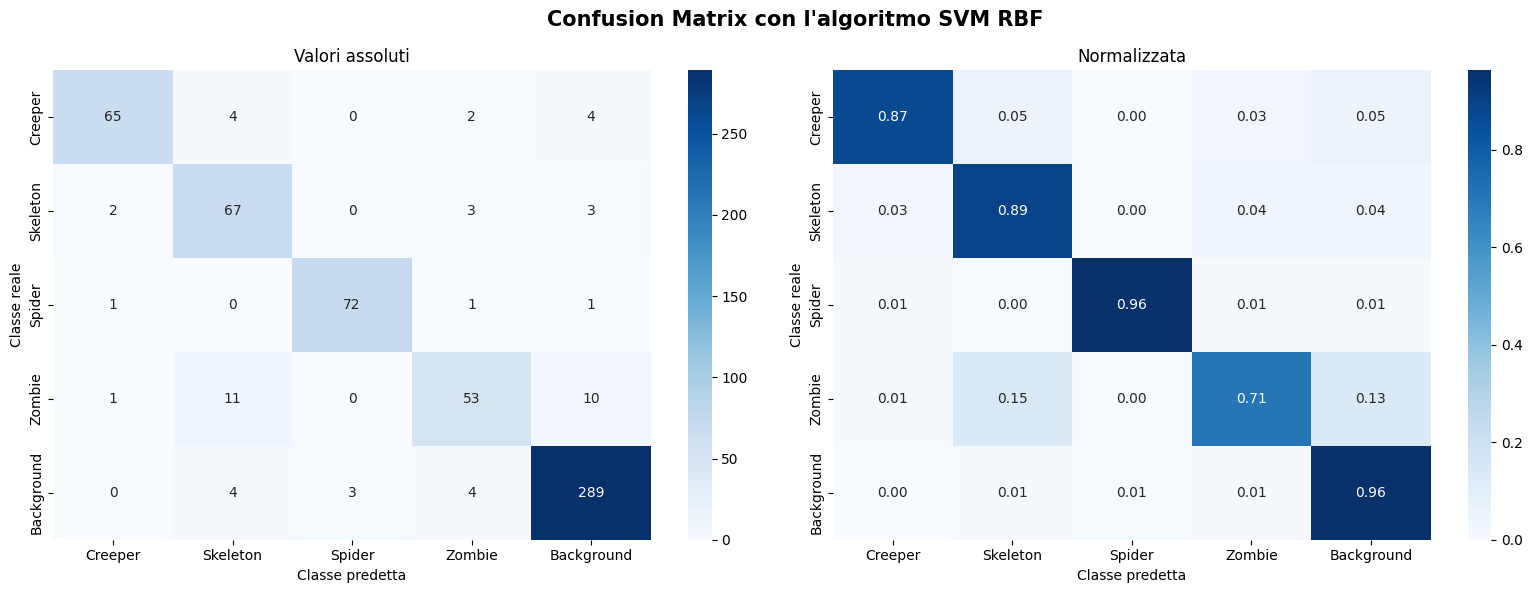

Classification report con l'algoritmo SVM RBF (solo classi mob):
              precision    recall  f1-score   support

     Creeper       0.94      0.92      0.93        71
    Skeleton       0.82      0.93      0.87        72
      Spider       1.00      0.97      0.99        74
      Zombie       0.90      0.82      0.85        65

    accuracy                           0.91       282
   macro avg       0.91      0.91      0.91       282
weighted avg       0.92      0.91      0.91       282



In [16]:
# SEZIONE PER LA REALIZZAZIONE DELLA CONFUZIONE MATRIX ------------------------------------------------------------

# Confusion Matrix => tabella degli errori per classe
# Riga i = classe reale, Colonna j = classe predetta
matrice_conf = confusion_matrix(y_test, predizioni_migliori)

# Versione normalizzata => ogni riga divisa per il numero di campioni reali
# ci dice la percentuale di recall per ogni classe
matrice_conf_norm = matrice_conf.astype('float') / matrice_conf.sum(axis=1, keepdims=True) # al denominatore somo riga per riga con axis=1 e poi mantengo la forma 2d come keepdims

# Nomi di tutte le classi incluso background
nomi_tutte_classi = lista_classi + ["Background"]

fig, assi = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Confusion Matrix con l'algoritmo {nome_svm}", fontsize=15, fontweight='bold')

# Heatmap con valori assoluti
# annot=True => mostra i numeri nelle celle
# fmt='d' => formato intero
# cmap='Blues' => gradiente di blu (piu' scuro = numero piu' alto)
sns.heatmap(matrice_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomi_tutte_classi, yticklabels=nomi_tutte_classi,
            ax=assi[0])
assi[0].set_title("Valori assoluti")
assi[0].set_ylabel("Classe reale")
assi[0].set_xlabel("Classe predetta")

# Heatmap normalizzata (recall per classe)
sns.heatmap(matrice_conf_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=nomi_tutte_classi, yticklabels=nomi_tutte_classi,
            ax=assi[1])
assi[1].set_title("Normalizzata")
assi[1].set_ylabel("Classe reale")
assi[1].set_xlabel("Classe predetta")

plt.tight_layout()
plt.show()

# SEZIONE PER LA REALIZZAZIONE DELLE METRICHE ------------------------------------------------------------

# Classification Report => precision, recall, F1 per ogni classe

# Escludiamo sia nel test che previsione il background che non  ci interessa (goal qui è far si che sia in grado di predirre i mob)

# Solo sulle 4 classi mob (escludiamo background=4)
maschera_mob= y_test < 4  # True dove la classe e' un mob (0,1,2,3) senza il back
y_test_mob = y_test[maschera_mob]
pred_mob = predizioni_migliori[maschera_mob]

# Filtriamo anche le predizioni che hanno dato classe 4
maschera_valid = pred_mob < 4
y_test_mob = y_test_mob[maschera_valid]
pred_mob = pred_mob[maschera_valid]

print(f"Classification report con l'algoritmo {nome_svm} (solo classi mob):")
# classification_report => genera una tabella con P, R, F1 per ogni classe
# labels=[0,1,2,3] => consideriamo solo le 4 classi mob
# target_names => nomi leggibili delle classi
print(classification_report(
    y_test_mob, pred_mob,
    labels=[0, 1, 2, 3],
    target_names=lista_classi
))


Sul totale 1600 di cui il 25% nel tes 400. togliendo i background sono circa 300 di cui 281 sono mob che svm ha predetto e i 18 li ha classificati come background

- Spider => il modello migliore (F1=0.99)
Precision=1.00 significa che ogni volta che il modello dice Spider ha sempre ragione. Recall=0.97 significa che trova il 97% degli Spider reali. Lo Spider è la classe più facile, ha una forma molto distintiva (basso e largo, 8 zampe visibili) che HOG cattura perfettamente.

- Creeper => buono (F1=0.93)
Precision=0.94 e Recall=0.92 ben bilanciati. Il Creeper ha una silhouette verticale caratteristica e il verde brillante aiuta a distinguerlo dagli altri mob anche in grayscale (il verde tende a essere più luminoso).

- Skeleton => recall alto ma precision bassa (F1=0.87)
Recall=0.93 significa che trova quasi tutti gli Skeleton. Ma Precision=0.82 significa che il 18% delle volte dice Skeleton quando non lo è. Probabile confusione con il Zombie, entrambi sono verticali e simili in grayscale.

- Zombie => il peggiore (F1=0.85)
Recall=0.82 è il più basso, perde il 18% degli Zombie reali. Il Zombie ha molte varianti (Drowned, Husk) con forme diverse che confondono il modello.

- Accuracy globale è 0.91
Su 282 mob totali ne classifica correttamente 257. È un risultato buono per HOG+ SVM considerando che lavora su crop 64x128 grayscale senza alcuna informazione sul colore.

HOG+SVM funziona bene sulle classi con forme distintive (Spider, Creeper) ma fatica sulle classi morfologicamente simili (Skeleton vs Zombie).

## 7. Detection => Sliding Window + Image Pyramid + NMS

Allora prima aveva fatto delle previsioni usando solamente i crop, nella realtà dei fatti l'algoritmo dovrà trovare il mob in un'immagine 1920x1080.

Il processo è il seguente: imagine 1920x1080 => image pyramic (3 o 4 scale diverse) => slidng window (finistra 64x128 che scorre) => HOG +SVM su ogni finestra e NMS rimuove i dupplicati

Quindi:
- Image pyramid => Per rilevare mob a distanze diverse usiamo una piramide di immagini (scale diverse).
- Sliding window => Su ogni livello scorriamo una finestra 64x128 e classifichiamo ogni patch con HOG+SVM.
- NMS => La sliding window trova lo stesso mob con molte finestre sovrapposte. => NMS tiene solo quella con confidence piu' alta e scarta le altre. => Usa IoU (Intersection over Union) per decidere se due box si sovrappongono => IoU = Area_Intersezione / Area_Unione


In [17]:
# PREPARAZIONE FUNZIONE PER LA IMAGE PYRAMID ---------------------------------------------------------------------------

# Funzione per creare la piramide di immagini (scale diverse)
def crea_piramide(immagine, fattore_scala=0.7, dimensione_minima=(64, 128)):

    # Genera copie dell'immagine a scale decrescenti.
    # Ogni livello e' il fattore_scala% del precedente.
    # Si ferma quando l'immagine diventa piu' piccola della finestra.

    scala_corrente = 1.0  # partiamo dalla dimensione originale
    yield immagine.copy(), scala_corrente  # primo livello è immagine originale

    altezza, larghezza = immagine.shape[:2]

    while True:
        scala_corrente = scala_corrente * fattore_scala  # riduciamo la scala

        nuova_larghezza = int(larghezza * scala_corrente)
        nuova_altezza   = int(altezza * scala_corrente)

        # Ci fermiamo se l'immagine e' piu' piccola della finestra HOG 64X128
        if nuova_larghezza < dimensione_minima[0] or nuova_altezza < dimensione_minima[1]:
            break

        # cv2.resize() => ridimensioniamo l'immagine
        immagine_ridotta = cv2.resize(immagine, (nuova_larghezza, nuova_altezza))
        yield immagine_ridotta, scala_corrente

# PREPARAZIONE FUNZIONE PER LA IOU ---------------------------------------------------------------------------

# Funzione per calcolare l'IoU tra due bounding box
def calcola_iou(box1, box2):

    # Calcola IoU = Area_Intersezione / Area_Unione tra due box [x1,y1,x2,y2].
    # IoU = 1 -> box identici
    # IoU = 0 -> box completamente separati

    # Coordinate dell'intersezione
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])

    # Area dell'intersezione (0 se non si sovrappongono)
    largh_inter = max(0, x2_inter - x1_inter)
    altez_inter = max(0, y2_inter - y1_inter)
    area_inter  = largh_inter * altez_inter

    # Area di ciascun box
    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    # Il calcolo è dato [a, b, c, d] => a = bordo sinistro; b = bordo superiore; c = boro destro; d = bordo inferiore
    # (bordo destro - bordo sinistro) * (bordo inferiore - bordo superiore) => dimensione del mio box in pixel

    # Area dell'unione (senza l'interesezione)
    area_unione = area_box1 + area_box2 - area_inter

    if area_unione == 0:
        return 0.0

    return area_inter / area_unione # Se l'IoU fosse 1.0 i box sarebbero identici, se fosse 0 non si toccano affatto.

# PREPARAZIONE FUNZIONE PER LA NMS ---------------------------------------------------------------------------

# Funzione NMS (Non-Maximum Suppression)
def applica_nms(lista_box, lista_score, soglia_iou=0.3):

    # Rimuove i bounding box duplicati mantenendo solo quello con score piu' alto.

    # Algoritmo:
    # 1. Ordina i box per score decrescente
    # 2. Prendi il box con score piu' alto -> lo tieni
    # 3. Calcola IoU con tutti i rimanenti
    # 4. Rimuovi quelli con IoU > soglia (sono duplicati)
    # 5. Ripeti finche' non rimangono box

    if len(lista_box) == 0:
        return []

    # Ordina per score decrescente
    # argsort() restituisce gli indici che ordinerebbero l'array
    # [::-1] inverte l'ordine (dal piu' grande al piu' piccolo)
    ordine = np.argsort(lista_score)[::-1]

    indici_mantenuti = []

    while len(ordine) > 0:
        # Prendiamo il box con score piu' alto
        idx_corrente = ordine[0]
        indici_mantenuti.append(idx_corrente)

        # Calcoliamo IoU con tutti i rimanenti
        da_rimuovere = []
        for j in range(1, len(ordine)):
            idx_altro = ordine[j]
            iou = calcola_iou(lista_box[idx_corrente], lista_box[idx_altro])
            if iou > soglia_iou:
                da_rimuovere.append(j)  # questo e' un duplicato, infatti verso l'uno dentono ad essere identici

        # Rimuoviamo i duplicati dall'ordine
        ordine = np.delete(ordine, [0] + da_rimuovere) # rimuovo il primo box che ho salvato con lo score alto [0] e gli altri dupplicati => qui l'obiettivo è raccogliere box con score alto e senza dupplicati

    return indici_mantenuti

print("Image Pyramid, IoU e NMS definiti")

# Test IoU
box_a = [100, 100, 200, 200]
box_b = [150, 150, 250, 250]
box_c = [300, 300, 400, 400]
print(f"IoU box sovrapposti (A,B): {calcola_iou(box_a, box_b)}")
# Si sovrappongono in una zona di 50x50 = 2.500 pixel. L'unione è più grande. Il risultato 0.143 significa che la sovrapposizione è circa il 14% dell'area totale unita, sovrapposizione bassa.
print(f"IoU box separati (A,C):    {calcola_iou(box_a, box_c)}")
# IoU = 0.0 = nessuna sovrapposizione.


Image Pyramid, IoU e NMS definiti
IoU box sovrapposti (A,B): 0.14285714285714285
IoU box separati (A,C):    0.0


In [19]:
# CREAZIONE FUNZIONE DELLA PIPELINE COMPLETA HOG+SVM CON ANCHE LA DETECTION --------------------------------------------------------------------------------

# Pipeline: Image Pyramid + Sliding Window + HOG + SVM + NMS

def rileva_mob_hog_svm(immagine_bgr, hog_desc, svm_model, scaler_model,
                        passo=32, fattore_scala=0.75,
                        soglia_confidenza=0.5, soglia_nms=0.3):

    # Applica la detection completa su una singola immagine.
    # Ritorna una lista di detection: (x1, y1, x2, y2, id_classe, confidenza)

    # Convertiamo in grayscale e equalizziamo (come i crop di training)
    gray = cv2.cvtColor(immagine_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)

    altezza_orig, larghezza_orig = gray.shape[:2]
    largh_finestra, altez_finestra = hog_desc.winSize  # 64, 128

    tutti_box = []  # tutti i bounding box trovati
    tutti_score = []  # confidence di ogni box
    tutte_classi = [] # classe di ogni box

    # Scorriamo la piramide di scale
    for immagine_scala, scala in crea_piramide(gray, fattore_scala):
        altezza_s, larghezza_s = immagine_scala.shape[:2]

        # Sliding window=> scorriamo la finestra sull'immagine
        for y in range(0, altezza_s - altez_finestra + 1, passo):
            for x in range(0, larghezza_s - largh_finestra + 1, passo):

                # Ritagliamo la finestra corrente
                finestra = immagine_scala[y:y+altez_finestra, x:x+largh_finestra]

                # Estraiamo le feature HOG dalla finestra
                feature = hog_desc.compute(finestra).flatten().reshape(1, -1)

                # Normalizziamo con lo stesso scaler del training
                feature_scalata = scaler_model.transform(feature)

                # Classifichiamo con SVM
                predizione = svm_model.predict(feature_scalata)[0]

                # Se e' un mob (non background)
                if predizione < 4:
                    # Calcoliamo la confidenza dalla decision function
                    # La decision function da' la distanza dall'iperpiano
                    decisione = svm_model.decision_function(feature_scalata)
                    confidenza = float(np.max(np.abs(decisione)))

                    if confidenza > soglia_confidenza:
                        # Riconvertiamo le coordinate alla scala originale
                        x1 = int(x / scala)
                        y1 = int(y / scala)
                        x2 = int((x + largh_finestra) / scala)
                        y2 = int((y + altez_finestra) / scala)

                        tutti_box.append([x1, y1, x2, y2])
                        tutti_score.append(confidenza)
                        tutte_classi.append(int(predizione))

    if len(tutti_box) == 0:
        return []

    # Applichiamo NMS per rimuovere i duplicati
    indici_mantenuti = applica_nms(tutti_box, tutti_score, soglia_nms)

    # Costruiamo la lista finale delle detection
    detection_finali = []
    for idx in indici_mantenuti:
        x1, y1, x2, y2 = tutti_box[idx]
        detection_finali.append((x1, y1, x2, y2, tutte_classi[idx], tutti_score[idx]))

    return detection_finali

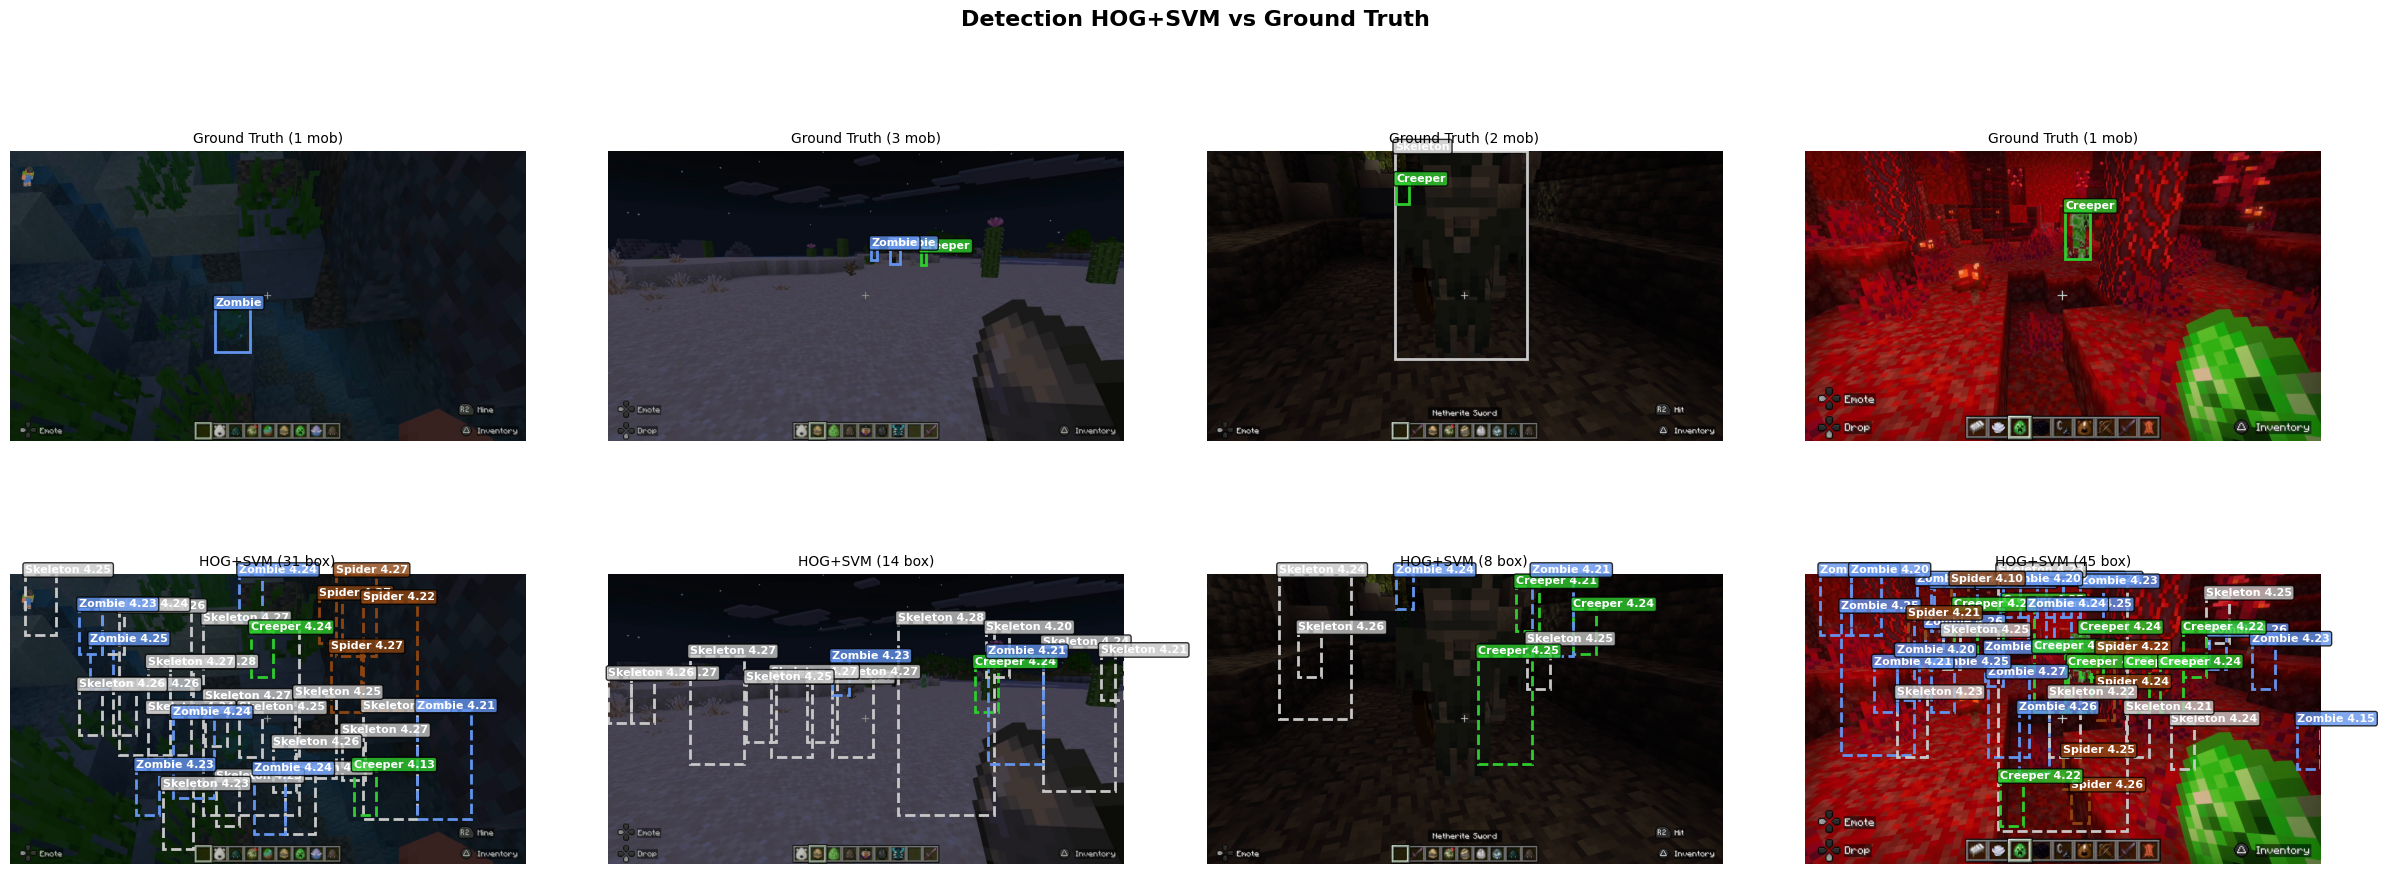

In [23]:
# TEST DELLA PIPELINE HOG+SVM CON LA DETECTION (TEST SU 4 IMMAGINI)
# Confrontiamo visivamente le predizioni del nostro modello con le annotazioni reali (Ground Truth)

# Raccogliamo tutte le immagini del validation set (jpg e png)
# sorted() le ordina in ordine alfabetico
lista_immagini_val = sorted(
    list(cartella_img_val.glob("*.jpg")) +
    list(cartella_img_val.glob("*.png"))
)

# Teniamo solo le immagini che hanno almeno un mob annotato
# val_con_mob sara' una lista di tuple (percorso_img, percorso_label, lista_box)
val_con_mob = []
for img_file in lista_immagini_val:

    # Costruiamo il percorso del file .txt corrispondente all'immagine
    file_label = cartella_lbl_val / (img_file.stem + ".txt")

    # Leggiamo i bounding box dal file .txt
    box_list = leggi_annotazione_yolo(file_label)

    # Se la lista non e' vuota aggiungiamo una tupla con le 3 informazioni utili
    if box_list:
        val_con_mob.append((img_file, file_label, box_list))

# Scegliamo 4 immagini casuali dalla lista
# min(4, len(val_con_mob)) => evita errori se ci sono meno di 4 immagini disponibili
campione_test = random.sample(val_con_mob, min(4, len(val_con_mob)))

# Creiamo una griglia di grafici 2 righe x 4 colonne
# RGround Truth (le annotazioni reali)
# Predizioni HOG+SVM (quello che trova il nostro modello)
fig, assi = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle("Detection HOG+SVM vs Ground Truth", fontsize=16, fontweight='bold')

# Colori per ogni classe in formato RGB normalizzato
colori_mob = {
    0: (0.18, 0.80, 0.18),  # Verde => Creeper
    1: (0.78, 0.78, 0.78),  # Grigio => Skeleton
    2: (0.55, 0.27, 0.07),  # Marrone => Spider
    3: (0.39, 0.58, 0.93),  # Blu => Zombie
}

# Cicliamo sulle 4 immagini scelte
# enumerate() ci da' sia l'indice (0,1,2,3) che il valore (la tupla)
for indice, (percorso_img, percorso_lbl, ground_truth) in enumerate(campione_test):

    # Carichiamo l'immagine in BGR (OpenCV) e la convertiamo in RGB (Matplotlib)
    img_bgr = cv2.imread(str(percorso_img))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Prendiamo le dimensioni reali in pixel
    altezza, larghezza = img_bgr.shape[:2]

    # GROUND TRUTH (annotazioni reali del dataset) ----------------------------------------------------------

    # Selezioniamo il grafico nella riga 0, colonna "indice"
    ax_gt = assi[0, indice]

    # Mostriamo l'immagine nel grafico
    ax_gt.imshow(img_rgb.copy())

    # Disegniamo i bounding box reali sopra l'immagine
    for box in ground_truth:

        # Spachettiamo la tupla con le 5 informazioni del box YOLO
        id_c, xc, yc, bw, bh = box

        # Saltiamo eventuali classi non valide (es. classe 4 = background)
        if id_c not in nomi_classi:
            continue

        # Convertiamo da coordinate YOLO normalizzate [0,1] a pixel assoluti
        x1 = int((xc - bw/2) * larghezza) # bordo sinistro in pixel
        y1 = int((yc - bh/2) * altezza) # bordo superiore in pixel
        largh_box = int(bw * larghezza) # larghezza del box in pixel
        altez_box = int(bh * altezza) # altezza del box in pixel

        # Prendiamo il colore della classe (se non esiste usiamo bianco)
        colore = colori_mob.get(id_c, (1, 1, 1))

        # Creiamo il rettangolo del bounding box
        # facecolor='none' => interno trasparente, vediamo l'immagine sotto
        rect = patches.Rectangle(
            (x1, y1),          # angolo in alto a sinistra
            largh_box,         # larghezza
            altez_box,         # altezza
            lw=2,              # spessore bordo
            edgecolor=colore,  # colore bordo
            facecolor='none'   # interno trasparente
        )
        ax_gt.add_patch(rect)  # aggiungiamo il rettangolo al grafico

        # Scriviamo il nome del mob sopra il box
        ax_gt.text(x1, y1-5, nomi_classi[id_c],
                    fontsize=8, color='white', fontweight='bold',
                    bbox=dict(facecolor=colore, alpha=0.8, boxstyle='round,pad=0.2'))

    ax_gt.set_title(f"Ground Truth ({len(ground_truth)} mob)", fontsize=10)
    ax_gt.axis('off')  # nascondiamo gli assi numerici

    # PREDIZIONI HOG+SVM (quello che trova il modello) ---------------------------------------------------------

    ax_pred = assi[1, indice]
    ax_pred.imshow(img_rgb.copy())

    # Lanciamo la detection completa sull'immagine

    # Questi sono i parametri iniziali che ho inserito:
    # passo=24 => la finestra si sposta di 24 pixel alla volta
    # fattore_scala=0.8 => ogni livello della piramide e' l'80% del precedente
    # soglia_confidenza=0.8 => teniamo solo i box dove SVM e' molto sicuro
    # soglia_nms=0.3 => due box con IoU > 0.3 sono considerati duplicati

    # Ho provato ad aumentare la soglia di confidenza 3.5 per predizione positive e diminuito la soglia nms per eliminare box poco sovrapposti
    # queste modifiche di parametri non hanno portato a miglioramenti significativi (troppi falsi positivi), quindi ho lasciato gli ultimi valori usati
    detection = rileva_mob_hog_svm(
        img_bgr, hog_descriptor, svm_migliore, scaler,
        passo=32, fattore_scala=0.75,
        soglia_confidenza=3.5, soglia_nms=0.1
    )

    # Disegniamo i box trovati dal modello
    for det in detection:

        # Spachettiamo la tupla con le 6 informazioni della detection
        x1, y1, x2, y2, id_c, conf = det

        colore = colori_mob.get(id_c, (1, 1, 1))

        # linestyle='--' => bordo tratteggiato per distinguerlo dal Ground Truth
        rect = patches.Rectangle(
            (x1, y1),
            x2-x1, y2-y1,    # larghezza e altezza dal punto in basso a destra
            lw=2,
            edgecolor=colore,
            facecolor='none',
            linestyle='--'    # tratteggiato => e' una predizione, non la verita'
        )
        ax_pred.add_patch(rect)

        # Mostriamo nome classe e confidence (es. "Zombie 0.92")
        ax_pred.text(x1, y1-5, f"{nomi_classi.get(id_c, '?')} {conf:.2f}",
                      fontsize=8, color='white', fontweight='bold',
                      bbox=dict(facecolor=colore, alpha=0.8, boxstyle='round,pad=0.2'))

    ax_pred.set_title(f"HOG+SVM ({len(detection)} box)", fontsize=10)
    ax_pred.axis('off')

# Etichette sulla sinistra per identificare le due righe
assi[0, 0].set_ylabel("Ground Truth", fontsize=12, fontweight='bold')
assi[1, 0].set_ylabel("HOG+SVM", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## Conclusioni

*   Dataset preparato: 2.400 crop totali di cui 1.200 positivi (300 per classe) e 1.200 negativi (background). Ogni crop è 64x128 grayscale. HOG ha estratto un vettore di 3.780 feature per ogni crop, producendo una matrice finale 2.400 x 3.780.
*   Baseline k-NN: il miglior k era k=1 con accuracy 0.843. Questo è il punto di partenza minimo da battere.
*   SVM Lineare: accuracy 0.835, più basso del k-NN, kernel lineare non sufficiente.
*   SVM RBF: accuracy 0.910, il migliore, batte sia k-NN che SVM Lineare. Modello scelto.
*   Detection sull'immagine intera: troppi falsi positivi (sliding window genera centinaia di box su sfondo). Questo dimostra il limite di HOG+SVM.
